In [1]:
# Install the packages used in this project
%pip install -q yfinance

# Import libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make charts look cleaner
plt.style.use("seaborn-v0_8-whitegrid")

print("Setup complete.")

Setup complete.


In [2]:
# Project settings
ticker = "ASML"
start_date = "2021-09-26"   # Five years of historical data
end_date = "2026-09-26"

# Download daily ASML market data
asml_data = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

# Check that the download worked
print(f"Rows downloaded: {len(asml_data)}")
print(f"First available date: {asml_data.index.min().date()}")
print(f"Last available date: {asml_data.index.max().date()}")

# Display the first five rows
asml_data.head()

Rows downloaded: 1255
First available date: 2021-09-27
Last available date: 2026-09-25


Price,Close,High,Low,Open,Volume
Ticker,ASML,ASML,ASML,ASML,ASML
Date,,,,,
2021-09-27,796.953552,808.946360,794.797319,804.557610,1063900
2021-09-28,744.345398,762.635174,737.571446,758.341809,2390100
2021-09-29,715.961548,750.127191,714.721254,748.953690,2216000
2021-09-30,710.895325,727.315081,708.204809,719.615640,1078800
2021-10-01,707.747009,710.790531,694.924155,710.790531,1180400


Number of usable price observations: 1255
Starting ASML price: $796.95
Latest ASML price: $1,743.94


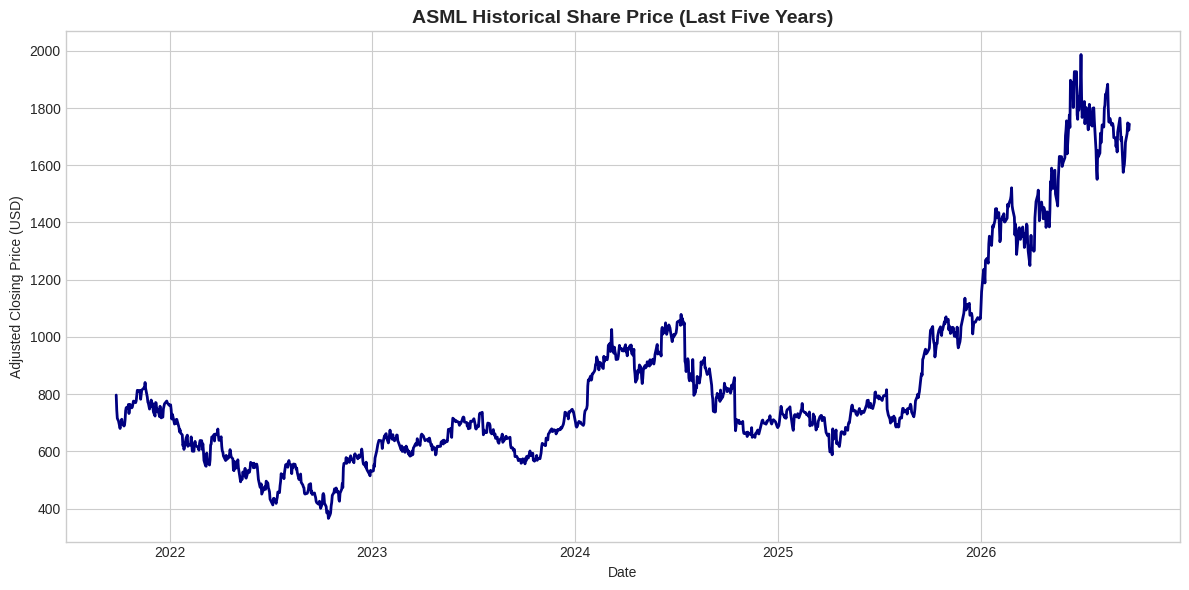

In [3]:
# Keep only the adjusted closing-price series and rename it clearly
prices = asml_data[["Close"]].copy()
prices.columns = ["ASML_Close"]

# Remove missing values, if any
prices = prices.dropna()

# Quick checks
print(f"Number of usable price observations: {len(prices)}")
print(f"Starting ASML price: ${prices['ASML_Close'].iloc[0]:,.2f}")
print(f"Latest ASML price: ${prices['ASML_Close'].iloc[-1]:,.2f}")

# Plot ASML's five-year historical share-price performance
plt.figure(figsize=(12, 6))
plt.plot(prices.index, prices["ASML_Close"], color="navy", linewidth=2)

plt.title("ASML Historical Share Price (Last Five Years)", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price (USD)")
plt.tight_layout()
plt.show()

In [4]:
# Calculate ASML's daily percentage returns
prices["Daily_Return"] = prices["ASML_Close"].pct_change()

# Remove the first row, which has no previous day to compare against
returns = prices["Daily_Return"].dropna()

# Historical daily statistics
mean_daily_return = returns.mean()
daily_volatility = returns.std()

# Annualised statistics, assuming approximately 252 trading days per year
trading_days = 252
annualised_return = mean_daily_return * trading_days
annualised_volatility = daily_volatility * np.sqrt(trading_days)

# Display the assumptions clearly
print(f"Average daily return: {mean_daily_return:.4%}")
print(f"Daily volatility: {daily_volatility:.4%}")
print(f"Annualised return: {annualised_return:.2%}")
print(f"Annualised volatility: {annualised_volatility:.2%}")

Average daily return: 0.1001%
Daily volatility: 2.7441%
Annualised return: 25.23%
Annualised volatility: 43.56%


In [5]:
# Monte Carlo simulation settings
initial_investment = 10_000
simulation_years = 3
num_simulations = 10_000
num_days = trading_days * simulation_years

# Use the latest historical ASML price as the starting point
starting_price = prices["ASML_Close"].iloc[-1]

# Set a seed so the results are reproducible
np.random.seed(42)

# Display the simulation assumptions
print("Monte Carlo Simulation Assumptions")
print("-" * 35)
print(f"Starting ASML share price: ${starting_price:,.2f}")
print(f"Initial investment: ${initial_investment:,.0f}")
print(f"Simulation horizon: {simulation_years} years ({num_days} trading days)")
print(f"Number of simulations: {num_simulations:,}")

Monte Carlo Simulation Assumptions
-----------------------------------
Starting ASML share price: $1,743.94
Initial investment: $10,000
Simulation horizon: 3 years (756 trading days)
Number of simulations: 10,000


In [6]:
# Generate random daily shocks for all simulations
random_shocks = np.random.normal(
    loc=0,
    scale=1,
    size=(num_days, num_simulations)
)

# Simulate daily ASML price changes using geometric Brownian motion
daily_returns_simulated = np.exp(
    (mean_daily_return - 0.5 * daily_volatility**2)
    + daily_volatility * random_shocks
)

# Create simulated ASML price paths
simulated_prices = starting_price * np.vstack(
    [np.ones(num_simulations), daily_returns_simulated]
).cumprod(axis=0)

# Check the shape of the simulation output
print(f"Simulation matrix shape: {simulated_prices.shape}")
print(f"Simulated trading days: {simulated_prices.shape[0] - 1}")
print(f"Simulated price paths: {simulated_prices.shape[1]:,}")

Simulation matrix shape: (757, 10000)
Simulated trading days: 756
Simulated price paths: 10,000


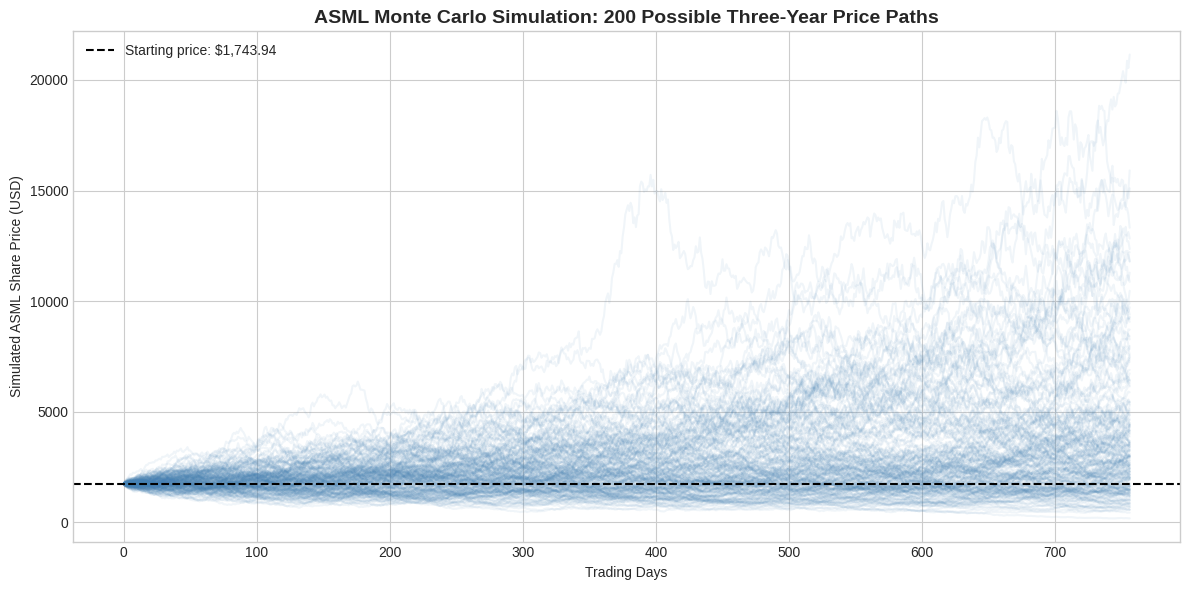

In [7]:
# Plot a readable sample of simulated ASML price paths
plt.figure(figsize=(12, 6))

for i in range(200):
    plt.plot(simulated_prices[:, i], color="steelblue", alpha=0.08)

plt.axhline(
    starting_price,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Starting price: ${starting_price:,.2f}"
)

plt.title("ASML Monte Carlo Simulation: 200 Possible Three-Year Price Paths",
          fontsize=14, fontweight="bold")
plt.xlabel("Trading Days")
plt.ylabel("Simulated ASML Share Price (USD)")
plt.legend()
plt.tight_layout()

plt.savefig("simulated_price_paths.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
# Calculate the number of ASML shares purchased with the initial investment
shares_purchased = initial_investment / starting_price

# Convert each simulated price path into a simulated portfolio-value path
simulated_portfolio_values = simulated_prices * shares_purchased

# Keep only the ending value of each three-year simulation
final_portfolio_values = simulated_portfolio_values[-1]

print(f"Shares purchased at the starting price: {shares_purchased:.4f}")
print(f"Number of final outcomes: {len(final_portfolio_values):,}")

Shares purchased at the starting price: 5.7341
Number of final outcomes: 10,000


In [9]:
# Calculate key ending-value statistics
median_final_value = np.median(final_portfolio_values)
mean_final_value = np.mean(final_portfolio_values)
percentile_5 = np.percentile(final_portfolio_values, 5)
percentile_95 = np.percentile(final_portfolio_values, 95)

# Calculate downside risk metrics
probability_of_loss = np.mean(final_portfolio_values < initial_investment)
probability_of_profit = np.mean(final_portfolio_values > initial_investment)

# Display results
print("Three-Year Monte Carlo Simulation Results")
print("-" * 42)
print(f"Initial investment: ${initial_investment:,.0f}")
print(f"Median final portfolio value: ${median_final_value:,.2f}")
print(f"Mean final portfolio value: ${mean_final_value:,.2f}")
print(f"5th percentile final value: ${percentile_5:,.2f}")
print(f"95th percentile final value: ${percentile_95:,.2f}")
print(f"Probability of loss: {probability_of_loss:.2%}")
print(f"Probability of profit: {probability_of_profit:.2%}")

Three-Year Monte Carlo Simulation Results
------------------------------------------
Initial investment: $10,000
Median final portfolio value: $15,979.31
Mean final portfolio value: $21,251.16
5th percentile final value: $4,715.50
95th percentile final value: $55,683.17
Probability of loss: 26.69%
Probability of profit: 73.31%


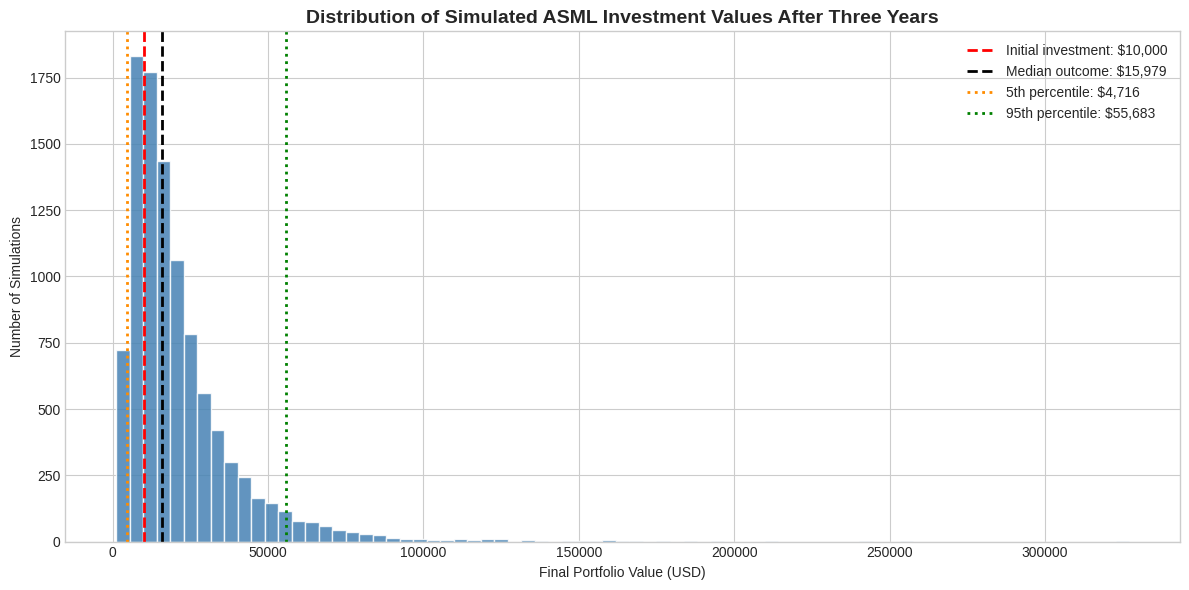

In [10]:
# Visualise the distribution of simulated three-year investment outcomes
plt.figure(figsize=(12, 6))

plt.hist(
    final_portfolio_values,
    bins=75,
    color="steelblue",
    edgecolor="white",
    alpha=0.85
)

plt.axvline(
    initial_investment,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Initial investment: ${initial_investment:,.0f}"
)

plt.axvline(
    median_final_value,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Median outcome: ${median_final_value:,.0f}"
)

plt.axvline(
    percentile_5,
    color="darkorange",
    linestyle=":",
    linewidth=2,
    label=f"5th percentile: ${percentile_5:,.0f}"
)

plt.axvline(
    percentile_95,
    color="green",
    linestyle=":",
    linewidth=2,
    label=f"95th percentile: ${percentile_95:,.0f}"
)

plt.title("Distribution of Simulated ASML Investment Values After Three Years",
          fontsize=14, fontweight="bold")
plt.xlabel("Final Portfolio Value (USD)")
plt.ylabel("Number of Simulations")
plt.legend()
plt.tight_layout()

plt.savefig("final_investment_value_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# Create a clean table for the README and GitHub repository
results_summary = pd.DataFrame({
    "Metric": [
        "Ticker",
        "Historical data period",
        "Simulation horizon",
        "Number of simulations",
        "Initial investment",
        "Starting ASML share price",
        "Historical annualised return",
        "Historical annualised volatility",
        "Median final portfolio value",
        "Mean final portfolio value",
        "5th percentile final value",
        "95th percentile final value",
        "Probability of loss",
        "Probability of profit"
    ],
    "Value": [
        ticker,
        f"{prices.index.min().date()} to {prices.index.max().date()}",
        f"{simulation_years} years ({num_days} trading days)",
        f"{num_simulations:,}",
        f"${initial_investment:,.0f}",
        f"${starting_price:,.2f}",
        f"{annualised_return:.2%}",
        f"{annualised_volatility:.2%}",
        f"${median_final_value:,.2f}",
        f"${mean_final_value:,.2f}",
        f"${percentile_5:,.2f}",
        f"${percentile_95:,.2f}",
        f"{probability_of_loss:.2%}",
        f"{probability_of_profit:.2%}"
    ]
})

results_summary

,Metric,Value
0,Ticker,ASML
1,Historical data period,2021-09-27 to 2026-09-25
2,Simulation horizon,3 years (756 trading days)
3,Number of simulations,"10,000"
4,Initial investment,"$10,000"
5,Starting ASML share price,"$1,743.94"
6,Historical annualised return,25.23%
7,Historical annualised volatility,43.56%
8,Median final portfolio value,"$15,979.31"
9,Mean final portfolio value,"$21,251.16"


In [12]:
# Save the results table as a CSV file for GitHub
results_summary.to_csv("simulation_summary.csv", index=False)

print("Export complete: simulation_summary.csv")

Export complete: simulation_summary.csv


In [13]:
# Print a short, data-driven project conclusion
print("Project Conclusion")
print("-" * 35)
print(
    f"Using five years of historical ASML data, the Monte Carlo model simulated "
    f"{num_simulations:,} possible three-year outcomes for a ${initial_investment:,.0f} investment."
)
print(
    f"The median simulated ending value was ${median_final_value:,.0f}, while the "
    f"central 90% of outcomes ranged from approximately ${percentile_5:,.0f} "
    f"to ${percentile_95:,.0f}."
)
print(
    f"Across the simulations, the estimated probability of finishing below the "
    f"initial ${initial_investment:,.0f} investment was {probability_of_loss:.1%}."
)
print(
    "These results are hypothetical scenario estimates based on historical return "
    "and volatility assumptions; they are not a forecast or investment recommendation."
)

Project Conclusion
-----------------------------------
Using five years of historical ASML data, the Monte Carlo model simulated 10,000 possible three-year outcomes for a $10,000 investment.
The median simulated ending value was $15,979, while the central 90% of outcomes ranged from approximately $4,716 to $55,683.
Across the simulations, the estimated probability of finishing below the initial $10,000 investment was 26.7%.
These results are hypothetical scenario estimates based on historical return and volatility assumptions; they are not a forecast or investment recommendation.


In [14]:
# Final validation checks
assert len(prices) > 1_000, "Too few historical price observations downloaded."
assert simulated_prices.shape == (num_days + 1, num_simulations), "Unexpected price simulation shape."
assert len(final_portfolio_values) == num_simulations, "Unexpected number of ending outcomes."
assert (final_portfolio_values > 0).all(), "Portfolio values should be positive."
assert 0 <= probability_of_loss <= 1, "Loss probability should fall between 0 and 1."

print("All validation checks passed.")
print()
print("Key results for the project:")
print(f"Historical data: {prices.index.min().date()} to {prices.index.max().date()}")
print(f"Starting ASML price: ${starting_price:,.2f}")
print(f"Median final value: ${median_final_value:,.2f}")
print(f"5th–95th percentile range: ${percentile_5:,.2f} to ${percentile_95:,.2f}")
print(f"Probability of loss: {probability_of_loss:.2%}")

All validation checks passed.

Key results for the project:
Historical data: 2021-09-27 to 2026-09-25
Starting ASML price: $1,743.94
Median final value: $15,979.31
5th–95th percentile range: $4,715.50 to $55,683.17
Probability of loss: 26.69%
